In [33]:
import random
import os
import json
from typing import Dict, Any
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
MODEL_FOR_INFERENCE = "nateraw/bert-base-uncased-emotion"

tokenizer = AutoTokenizer.from_pretrained(MODEL_FOR_INFERENCE)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_FOR_INFERENCE).to(device)
model.eval()

id2label = model.config.id2label
label2id = model.config.label2id
label_names = list(id2label.values())

print("Model loaded:", MODEL_FOR_INFERENCE)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", id2label)
print("Label names:", label_names)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nateraw/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: nateraw/bert-base-uncased-emotion
Tokenizer class: BertTokenizer
Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [3]:
def load_emotion_dataset(dataset_name="dair-ai/emotion", split_ratios=(0.7, 0.15, 0.15), seed=SEED):
    """
    Загружает датасет для классификации эмоций и разбивает на train/val/test.
    """
    print(f"Загрузка датасета: {dataset_name}")
    
    dataset = load_dataset(dataset_name, cache_dir="data/")
    
    full_df = None
    
    if 'train' in dataset:
        full_df = dataset['train'].to_pandas()
    elif 'validation' in dataset:
        # Иногда датасет сразу разбит на train/validation/test
        # В таком случае объединяем их или берем validation как основной
        full_df = dataset['validation'].to_pandas()
    elif 'default' in dataset:
        full_df = dataset['default'].to_pandas()
    else:
        # Берем первый доступный сплит
        first_key = list(dataset.keys())[0]
        full_df = dataset[first_key].to_pandas()
    
    # Проверка на случай, если датасет пуст
    if full_df is None or len(full_df) == 0:
        raise ValueError("Не удалось загрузить данные из датасета")

    # 2. Разбиваем на сплиты
    train_ratio, val_ratio, test_ratio = split_ratios
    
    # Сначала разбиваем на train+val и test
    train_val_df, test_df = train_test_split(
        full_df, 
        test_size=test_ratio, 
        random_state=seed,
        stratify=full_df['label'] if 'label' in full_df.columns else None
    )
    
    # Затем разбиваем train+val на train и val
    # val_ratio от оставшейся части (train_val)
    adjusted_val_ratio = val_ratio / (train_ratio + val_ratio)
    
    train_df, val_df = train_test_split(
        train_val_df, 
        test_size=adjusted_val_ratio, 
        random_state=seed,
        stratify=train_val_df['label'] if 'label' in train_val_df.columns else None
    )

    
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


train_df, val_df, test_df = load_emotion_dataset(
    split_ratios=(0.7, 0.15, 0.15),
)

# Sanity-check:
full_dataset_size = len(train_df) + len(val_df) + len(test_df)

print(f"Размер полного датаcета: {full_dataset_size}")

print(f"\nРазмеры датасетов:")
print(f"  Train: {len(train_df)} samples ({len(train_df)/full_dataset_size*100:.1f}%)")
print(f"  Val:   {len(val_df)} samples ({len(val_df)/full_dataset_size*100:.1f}%)")
print(f"  Test:  {len(test_df)} samples ({len(test_df)/full_dataset_size*100:.1f}%)")

print(f"Метки классов: {train_df['label'].unique()}")

if 'label' in train_df.columns:
    print(f"\nРаспределение классов в train:")
    print(train_df['label'].value_counts().sort_index())

# Показываем примеры данных
print("Примеры данных из train:")
print(train_df.head())

Загрузка датасета: dair-ai/emotion
Размер полного датаcета: 16000

Размеры датасетов:
  Train: 11200 samples (70.0%)
  Val:   2400 samples (15.0%)
  Test:  2400 samples (15.0%)
Метки классов: [0 1 3 4 2 5]

Распределение классов в train:
label
0    3266
1    3754
2     913
3    1511
4    1356
5     400
Name: count, dtype: int64
Примеры данных из train:
                                                text  label
0    i am feeling more like me except a little weepy      0
1  i feel disturbed because of the world i saw th...      0
2  i feel i am suffering from a bad case of i onl...      0
3  i feel like the audience is smart enough and k...      1
4  i wake up it hurts knowing that i could have e...      1


Датасет содержит короткие отрывки текста. Задача заключается в том, чтобы классифицировать их по эмоциональной окраске.

In [4]:
# Примеры токенизации
example_texts = [el for el in train_df['text']][:5]

# Используем padding
batch = tokenizer(
    example_texts,
    padding=True,
    return_tensors="pt",
)

print("input_ids shape:", tuple(batch["input_ids"].shape))
print("attention_mask shape:", tuple(batch["attention_mask"].shape))

for i in range(len(batch['input_ids'])):
    print(f'Исходный текст: {example_texts[i]}')
    ids = batch["input_ids"][i].tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)
    mask = batch["attention_mask"][i].tolist()

    display(
        pd.DataFrame(
            {
                "position": list(range(len(ids))),
                "token": tokens,
                "input_ids": ids,
                "attention_mask": mask,
            }
        )
    )

input_ids shape: (5, 30)
attention_mask shape: (5, 30)
Исходный текст: i am feeling more like me except a little weepy


,position,token,input_ids,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,am,2572,1
3,3,feeling,3110,1
4,4,more,2062,1
5,5,like,2066,1
6,6,me,2033,1
7,7,except,3272,1
8,8,a,1037,1
9,9,little,2210,1


Исходный текст: i feel disturbed because of the world i saw through the camera s eyes


,position,token,input_ids,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,feel,2514,1
3,3,disturbed,12491,1
4,4,because,2138,1
5,5,of,1997,1
6,6,the,1996,1
7,7,world,2088,1
8,8,i,1045,1
9,9,saw,2387,1


Исходный текст: i feel i am suffering from a bad case of i only want to nap


,position,token,input_ids,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,feel,2514,1
3,3,i,1045,1
4,4,am,2572,1
5,5,suffering,6114,1
6,6,from,2013,1
7,7,a,1037,1
8,8,bad,2919,1
9,9,case,2553,1


Исходный текст: i feel like the audience is smart enough and knows the characters well enough to figure out who were reading


,position,token,input_ids,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,feel,2514,1
3,3,like,2066,1
4,4,the,1996,1
5,5,audience,4378,1
6,6,is,2003,1
7,7,smart,6047,1
8,8,enough,2438,1
9,9,and,1998,1


Исходный текст: i wake up it hurts knowing that i could have ever possibly done anything to hurt this person to ever make him feel pain or lack of trusting


,position,token,input_ids,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,wake,5256,1
3,3,up,2039,1
4,4,it,2009,1
5,5,hurts,13403,1
6,6,knowing,4209,1
7,7,that,2008,1
8,8,i,1045,1
9,9,could,2071,1


In [5]:
# Инференс на готовой модели
def predict_one_text(text: str) -> Dict[str, Any]:
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)

    pred_id = int(torch.argmax(probs, dim=-1).item())
    pred_label = model.config.id2label[pred_id]
    pred_score = float(probs[0, pred_id].item())

    result = {
        "text": text,
        "pred_id": pred_id,
        "pred_label": pred_label,
        "pred_score": pred_score,
        "logits": logits.cpu().numpy().round(4).tolist()[0],
        "probabilities": probs.cpu().numpy().round(4).tolist()[0],
    }
    return result

num_predictions = 5
print("=== Результаты инференса на предобученной модели ===")
for i in range(num_predictions):
    text = test_df['text'][i]
    true_label = id2label[test_df['label'][i]]
    
    pred_result = predict_one_text(text)
    pred_label = id2label[pred_result['pred_id']]
    print(f"True label: {true_label}, Pred label: {pred_label}, Confidence: {round(pred_result['pred_score'], 4)}, Text: {text}")

=== Результаты инференса на предобученной модели ===
True label: fear, Pred label: fear, Confidence: 0.9912, Text: i want to say that i feel vulnerable writing and sharing this info
True label: joy, Pred label: joy, Confidence: 0.9958, Text: i have been using deborah lippmann hard rock as a base for a couple weeks and it seems to prevent staining exceedingly well so i ws feeling brave enough to try this modified french tip two coats of a peachy pink jelly sation love at first byte then a random black with a dotting tool for spots
True label: joy, Pred label: joy, Confidence: 0.9932, Text: i really didnt feel like running on saturday but decided i should to make sure i got my miles in for june
True label: fear, Pred label: fear, Confidence: 0.9917, Text: i rid myself of many bad habits only to fall back into them when i feel insecure or vulnerable
True label: love, Pred label: love, Confidence: 0.9879, Text: i find myself smiling at their feelings towards me and almost feeling affection

Данная модель отлично подходит под данную задачу, потому что она дообучена на этом конкретном датасете. Она показывает близкую к единице вероятность предсказанной метки класса.

In [14]:
MODEL_FOR_FINETUNING = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_FOR_FINETUNING,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

print(dataset_dict)
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 11200
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2400
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 2400
    })
})
Пример из train:


{'text': ['i am feeling more like me except a little weepy',
  'i feel disturbed because of the world i saw through the camera s eyes',
  'i feel i am suffering from a bad case of i only want to nap'],
 'labels': [0, 0, 0]}

Пример из validation:


{'text': ['i understand feeling alone and lonely like you may never be really known',
  'i was over tired and feeling irritable as a result',
  'i feel terribly unkind to say it span style font size'],
 'labels': [0, 3, 3]}

In [ ]:
def tokenize_batch(batch: Dict[str, list[str]]) -> Dict[str, list[list[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11200
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2400
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2400
    })
})

In [17]:
# Смотрим, как теперь выглядит один пример после токенизации.
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("labels:", example["labels"])
print("input_ids:", example["input_ids"])
print("attention_mask:", example["attention_mask"])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))

Ключи примера: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 0
input_ids: [101, 1045, 2572, 3110, 2062, 2066, 2033, 3272, 1037, 2210, 27874, 2100, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] i am feeling more like me except a little weepy [SEP]


In [ ]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")


labels: shape=(3,)
input_ids: shape=(3, 17)
token_type_ids: shape=(3, 17)
attention_mask: shape=(3, 17)


In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [24]:
common_training_kwargs = dict(
    output_dir="outputs/hw13_bert_finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    **common_training_kwargs,
)


training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [35]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )


MODEL_PATH = "outputs/hw13_bert_finetuning/checkpoint-4200"

if not os.path.exists(MODEL_PATH):
    train_result = trainer.train()
    print(train_result)
else:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,epoch,grad_norm,learning_rate,loss,step,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.001429,0.311177,0.00002,0.009963,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.002857,44.084766,0.00002,0.068517,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.004286,0.630110,0.00002,0.016376,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.005714,0.132929,0.00002,0.117397,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.007143,6.212409,0.00002,0.233234,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.008571,0.625011,0.00002,0.007885,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.010000,0.243963,0.00002,0.007440,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.011429,16.512383,0.00002,0.284682,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.012857,1.272873,0.00002,0.102354,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.014286,0.692589,0.00002,0.064877,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN


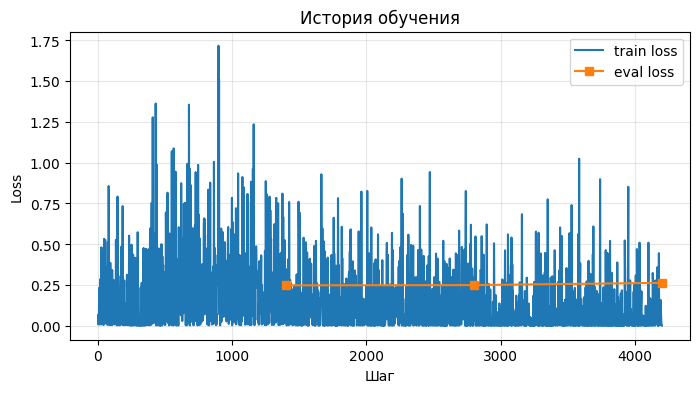

In [ ]:
state_path = os.path.join(MODEL_PATH, "trainer_state.json")

with open(state_path, "r", encoding="utf-8") as f: # загружаем историю из json
    trainer_state = json.load(f)

history_df = pd.DataFrame(trainer_state["log_history"])
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker='s', label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()